C:\Users\admin\AppData\Local\Temp\ipykernel_22600\4177371209.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gaze[0] += np.random.normal(0, 0.03, 1)
C:\Users\admin\AppData\Local\Temp\ipykernel_22600\4177371209.py:37: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gaze[1] += np.random.normal(0, 0.03, 1)
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['ST

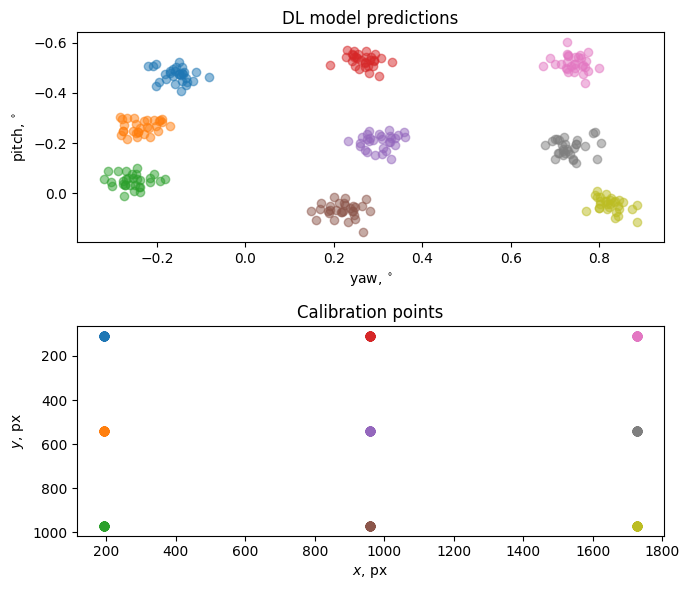

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.optimize as opt

class CalibrationDataGenerator:
    def __init__(self, width=1920, height=1080, points=9, samples_per_point=30):
        self.width = width
        self.height = height
        self.points = points
        self.samples = samples_per_point

    def generate(self):
        """Generate gaze data with random translations breaking perfect 9-point pattern"""
        grid = np.linspace(0.1, 0.9, 3)
        pogs = np.array([[x, y, 0] for x in grid for y in grid]) * [self.width, self.height, 1]

        base_gaze_grid_y = np.linspace(-0.5, 0.0, 3)
        base_gaze_grid_x = np.linspace(-0.2, 0.8, 3)
        gazes = np.array([[x, y, 1] for x in base_gaze_grid_x for y in base_gaze_grid_y])

        gaze_data = []

        for i, pog in enumerate(pogs):
            cluster_offset = np.random.uniform(-0.1, 0.1, 2)
            cluster_z_variation = np.random.uniform(0.9, 1.1)

            for _ in range(self.samples):
                gaze = gazes[i].copy()

                gaze[0] += cluster_offset[0]
                gaze[1] += cluster_offset[1]
                gaze[2] *= cluster_z_variation

                # Add per-sample noise (ocular tremor)
                gaze[0] += np.random.normal(0, 0.03, 1)
                gaze[1] += np.random.normal(0, 0.03, 1)

                gaze_data.append({
                    "idx": i,
                    "gaze_x": gaze[0],
                    "gaze_y": gaze[1],
                    "gaze_z": gaze[2],
                    "set_x": pog[0],
                    "set_y": pog[1],
                    "set_z": pog[2]
                })

        self.df = pd.DataFrame(gaze_data)
        return self

    def visualize(self):
        """Plot the generated data"""
        fig = plt.figure(figsize=(7, 6))
        colormap = plt.cm.tab10
        num_colors = 10  
        
        ax1 = fig.add_subplot(211)
        for i in range(self.points):
            subset = self.df[self.df['idx'] == i]
            # Get consistent color for this point
            color = colormap(i % num_colors)
            ax1.scatter(subset['gaze_x'], subset['gaze_y'], alpha=0.5, 
                        color=color, label=f'Point {i}')
        ax1.set_title('DL model predictions')
        ax1.set_xlabel('yaw, $^{\circ}$')
        ax1.set_ylabel('pitch, $^{\circ}$')
        plt.gca().invert_yaxis()

        ax2 = fig.add_subplot(212)
        for i in range(self.points):
            subset = self.df[self.df['idx'] == i]
            color = colormap(i % num_colors)
            ax2.scatter(subset['set_x'], subset['set_y'], color=color)
        ax2.set_title('Calibration points')
        ax2.set_xlabel('$x$, px')
        ax2.set_ylabel('$y$, px')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    gen = CalibrationDataGenerator().generate()
    gen.visualize()

Processing 9 calibration points
Optimization success: True, final cost: 1878767.2245


C:\Users\admin\AppData\Local\Temp\ipykernel_22600\1395410962.py:346: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


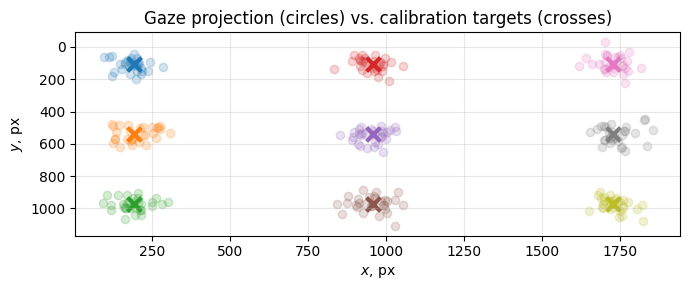

In [2]:
def inverse_homogeneous_matrix(T):
    """ 
    Inverse of a homogeneous transformation matrix.
    
    For a homogeneous matrix T = [R t; 0 1], its inverse is [R^T -R^T*t; 0 1].
    
    Parameters:
    -----------
    T : np.ndarray(4,4)
        Homogeneous transformation matrix
    
    Returns:
    --------
    inv_T : np.ndarray(4,4)
        Inverse of the transformation matrix T
    """
    R = T[0:3, 0:3]  # Rotation component
    t = T[0:3, 3]    # Translation component
    
    # Construct inverse: [R^T, -R^T * t; 0, 0, 0, 1]
    inv_T = np.r_[np.c_[R.T, -R.T @ t], np.array([[0, 0, 0, 1]])]
    return inv_T


def compute_gaze_scale(gaze_vector, screen_to_gaze_transform):
    """
    Compute scaling factor for gaze vectors to intersect screen plane.
    
    The scale projects gaze direction from gaze origin onto screen plane.
    
    Parameters:
    -----------
    gaze_vector : np.ndarray(3,) or np.ndarray(N,3)
        Gaze direction vector(s) in gaze coordinate system
    screen_to_gaze_transform : np.ndarray(4,4)
        Transformation from screen to gaze coordinate system
    
    Returns:
    --------
    scale : float or np.ndarray
        Scaling factor(s) for gaze vector(s)
    """
    # Forward gaze direction in gaze coordinates
    forward_gaze = np.array([[0], [0], [1]])
    
    # Get transformation from gaze to screen coordinates
    gaze_to_screen_transform = inverse_homogeneous_matrix(screen_to_gaze_transform)
    gaze_origin_in_screen = gaze_to_screen_transform[:3, 3].reshape(3, 1)
    
    # Compute scale using ray-plane intersection formula
    if np.ndim(gaze_vector) == 1:
        # Single gaze vector
        gaze_reshaped = gaze_vector[:, None]
        scale = (forward_gaze.T @ gaze_origin_in_screen) / (forward_gaze.T @ gaze_reshaped)
    elif np.ndim(gaze_vector) == 2:
        # Multiple gaze vectors (batch)
        scale = (forward_gaze.T @ gaze_origin_in_screen) / (forward_gaze.T @ gaze_vector[:, :, None])
    
    return scale


def project_gaze_to_screen(gaze_vectors_list, screen_to_gaze_transform, screen_origins_list):
    """
    Project gaze vectors onto screen coordinates.
    
    Parameters:
    -----------
    gaze_vectors_list : list of np.ndarray(N,3)
        List of gaze vectors for each calibration point
    screen_to_gaze_transform : np.ndarray(4,4)
        Base transformation from screen to gaze coordinates
    screen_origins_list : list of np.ndarray(3,1)
        List of screen origin positions for each calibration point
    
    Returns:
    --------
    screen_gaze_projected : list of np.ndarray(N,3)
        Gaze projected onto screen using base transform
    screen_gaze_calibrated : list of np.ndarray(N,3)
        Gaze projected onto screen using per-point transforms
    """
    screen_gaze_projected = [None] * len(gaze_vectors_list)
    screen_gaze_calibrated = [None] * len(gaze_vectors_list)
    
    # Extract rotation component (assumes screen and gaze have opposite orientations)
    screen_to_gaze_rotation = screen_to_gaze_transform[:3, :3]
    
    for i, gaze_vectors in enumerate(gaze_vectors_list):
        gaze_numpy = gaze_vectors.to_numpy()
        
        # Project using base transformation
        scale = compute_gaze_scale(gaze_numpy, screen_to_gaze_transform)
        screen_gaze_projected[i] = (
            screen_to_gaze_transform @ 
            np.concatenate((scale * gaze_numpy[:, :, None], 
                            np.ones((gaze_numpy.shape[0], 1, 1))), axis=1)
        )[:, :3, :]
        
        # Project using per-point calibrated transformation
        # Create transformation with per-point screen origin
        per_point_transform = np.vstack((
            np.hstack((screen_to_gaze_rotation, screen_origins_list[i].reshape(3, 1))),
            np.array([0, 0, 0, 1])
        ))
        
        scale_calibrated = compute_gaze_scale(gaze_numpy, per_point_transform)
        screen_gaze_calibrated[i] = (
            per_point_transform @ 
            np.concatenate((scale_calibrated * gaze_numpy[:, :, None], 
                            np.ones((gaze_numpy.shape[0], 1, 1))), axis=1)
        )[:, :3, :]
    
    return screen_gaze_projected, screen_gaze_calibrated


def compute_transformation_between_screen_and_gaze(
    screen_to_gaze_rotation, 
    screen_position, 
    gaze_direction, 
    gaze_scale
):
    """
    Compute transformation between screen and gaze coordinate systems.
    
    Parameters:
    -----------
    screen_to_gaze_rotation : np.ndarray(3,3)
        Rotation from screen to gaze coordinates
    screen_position : np.ndarray(3,1)
        Screen origin position in screen coordinates
    gaze_direction : np.ndarray(3,)
        Gaze direction vector in gaze coordinates
    gaze_scale : float
        Scale factor for gaze direction
    
    Returns:
    --------
    screen_to_gaze_transform : np.ndarray(4,4)
        Transformation from screen to gaze coordinates
    gaze_to_screen_transform : np.ndarray(4,4)
        Transformation from gaze to screen coordinates
    """
    # Screen to anchor transformation (screen position)
    screen_to_anchor_transform = np.vstack((
        np.hstack((np.eye(3), screen_position)),
        np.array([0, 0, 0, 1])
    ))
    
    # Anchor to gaze transformation (gaze direction scaled)
    anchor_to_gaze_transform = np.vstack((
        np.hstack((screen_to_gaze_rotation, 
                    -screen_to_gaze_rotation.T @ (gaze_scale * gaze_direction[:, None]))),
        np.array([0, 0, 0, 1])
    ))
    
    # Combined transformation: screen → anchor → gaze
    screen_to_gaze_transform = screen_to_anchor_transform @ anchor_to_gaze_transform
    
    # Inverse transformation: gaze → screen
    gaze_to_screen_transform = inverse_homogeneous_matrix(screen_to_gaze_transform)
    
    return screen_to_gaze_transform, gaze_to_screen_transform


def calibrate_screen_to_gaze_transform(
    gaze_vectors, 
    screen_targets, 
    dataframe, 
    gaze_vectors_by_point, 
    screen_positions_by_point,
    screen_resolution=None
):
    """
    Calibrate transformation from screen to gaze coordinate system.
    
    Parameters:
    -----------
    gaze_vectors : pd.DataFrame or np.ndarray
        All gaze direction vectors
    screen_targets : pd.DataFrame or np.ndarray
        All screen target positions
    dataframe : pd.DataFrame
        Complete dataset
    gaze_vectors_by_point : list of pd.DataFrame
        Gaze vectors grouped by calibration point
    screen_positions_by_point : list of np.ndarray(3,1)
        Screen positions for each calibration point
    screen_resolution : tuple, optional
        (width, height) of screen in pixels. If None, uses median of targets.
    
    Returns:
    --------
    screen_to_gaze_transform : np.ndarray(4,4)
        Calibrated transformation from screen to gaze coordinates
    screen_origins : np.ndarray(N,3,1)
        Screen origin positions for each calibration point
    """
    # Convert to numpy arrays
    gaze_numpy = gaze_vectors.to_numpy()
    target_numpy = screen_targets.to_numpy()
    
    # Fixed rotation: screen and gaze have opposite coordinate frames
    screen_to_gaze_rotation = np.array([[-1, 0, 0], [0, -1, 0], [0, 0, 1]])
    
    # Prepare data for optimization
    gaze_numpy = gaze_numpy[:, :, None]  # Add dimension for batch operations
    
    # Set initial guess for screen origin
    if screen_resolution is None:
        # Use median of all screen targets as initial guess
        initial_x = np.median(target_numpy[:, 0])
        initial_y = np.median(target_numpy[:, 1])
        initial_z = np.median(target_numpy[:, 2]) if target_numpy.shape[1] > 2 else 0
    else:
        width, height = screen_resolution
        initial_x = width / 2
        initial_y = height / 2
        initial_z = width  # Reasonable default distance
    
    def alignment_error(screen_origin_params, rotation_matrix, gaze_directions, screen_targets):
        """
        Error function for screen origin optimization.
        
        Computes difference between projected gaze points and actual screen targets.
        """
        # Extract screen origin from parameters
        screen_origin = np.array([[screen_origin_params[0]], 
                                    [screen_origin_params[1]], 
                                    [screen_origin_params[2]]])
        
        # Forward gaze direction in gaze coordinates
        forward_gaze = np.array([[0], [0], [1]])
        
        # Compute scale factors for all gaze directions
        mu = (forward_gaze.T @ (-rotation_matrix.T @ screen_origin)) / (forward_gaze.T @ gaze_directions)
        
        # Project gaze directions to screen coordinates
        projected_points = rotation_matrix @ (mu * gaze_directions) + screen_origin
        
        # Compute error: difference between projected points and actual targets
        error = screen_targets[:, :, None] - projected_points
        
        return error.flatten()
    
    # Optimization setup
    optimization_constants = (screen_to_gaze_rotation, gaze_numpy, target_numpy)
    initial_guess = np.array([initial_x, initial_y, initial_z])
    
    # Perform optimization
    result = opt.least_squares(
        alignment_error, 
        initial_guess, 
        args=optimization_constants
    )
    
    print(f"Optimization success: {result.success}, final cost: {result.cost:.4f}")
    
    # Extract optimized screen origin
    optimized_screen_origin = np.array([[result.x[0]], [result.x[1]], [result.x[2]]])
    
    # Create transformation matrix with optimized origin
    screen_to_gaze_transform = np.r_[
        np.c_[screen_to_gaze_rotation, optimized_screen_origin],
        np.array([[0, 0, 0, 1]])
    ]
    
    # Compute per-calibration-point screen origins
    num_calibration_points = len(gaze_vectors_by_point)
    screen_origins_per_point = [None] * num_calibration_points
    
    for i in range(num_calibration_points):
        # Use median gaze direction for this calibration point
        median_gaze = np.median(gaze_vectors_by_point[i].to_numpy(), axis=0)
        
        # Compute scale for this gaze direction
        gaze_scale = compute_gaze_scale(median_gaze, screen_to_gaze_transform)
        
        # Compute transformation with this point's specific screen position
        point_transform, _ = compute_transformation_between_screen_and_gaze(
            screen_to_gaze_rotation,
            screen_positions_by_point[i],
            median_gaze,
            gaze_scale
        )
        
        screen_origins_per_point[i] = point_transform[:3, 3, None]
    
    return screen_to_gaze_transform, np.array(screen_origins_per_point)


if __name__ == "__main__":
    idx = int(pd.unique(gen.df["idx"])[-1]) + 1
    print(f"Processing {idx} calibration points")
    
    # Group data by calibration point
    gaze_by_point = [None] * idx
    targets_by_point = [None] * idx
    transformations_by_point = [None] * idx
    
    for i in range(idx):
        gaze_by_point[i] = gen.df[gen.df["idx"] == i].loc[:, "gaze_x":"gaze_z"]
        targets_by_point[i] = gen.df[gen.df["idx"] == i].loc[:, "set_x":"set_z"]
        transformations_by_point[i] = gen.df[gen.df["idx"] == i].filter(like="WTransG")
    
    # Prepare data for calibration
    screen_positions = [v.to_numpy()[0][:, None] for v in targets_by_point]
    all_gaze_vectors = pd.concat(gaze_by_point, axis=0)
    all_screen_targets = pd.concat(targets_by_point, axis=0)
    all_transformations = pd.concat(transformations_by_point, axis=0)
    
    # Calibrate screen-to-gaze transformation
    screen_to_gaze_transform, screen_origins = calibrate_screen_to_gaze_transform(
        gaze_vectors=all_gaze_vectors,
        screen_targets=all_screen_targets,
        dataframe=gen.df,
        gaze_vectors_by_point=gaze_by_point,
        screen_positions_by_point=screen_positions,
        screen_resolution=(1920, 1080) 
    )
    
    # Project gaze vectors to screen coordinates
    gaze_projected, gaze_calibrated = project_gaze_to_screen(
        gaze_by_point,
        screen_to_gaze_transform,
        screen_origins
    )
    
    fig = plt.figure(figsize=(7, 3))
    colormap = plt.cm.tab10
    num_colors = 10
    
    for i in range(len(gaze_calibrated)):
        color = colormap(i % num_colors)
        
        # Plot projected gaze points
        plt.scatter(
            gaze_calibrated[i][:, 0, 0], 
            gaze_calibrated[i][:, 1, 0], 
            alpha=0.2, 
            color=color
        )
        
        # Plot actual screen targets for comparison 
        subset = gen.df[gen.df["idx"] == i]
        if not subset.empty:
            plt.scatter(
                subset["set_x"].iloc[0],  
                subset["set_y"].iloc[0], 
                marker="x", 
                s=100, 
                color=color,
                edgecolor="white", 
                linewidths=3
            )
    
    plt.xlabel("$x$, px")
    plt.ylabel("$y$, px")
    plt.title("Gaze projection (circles) vs. calibration targets (crosses)")
    plt.grid(True, alpha=0.3)
    plt.gca().invert_yaxis()
    
    plt.tight_layout()
    plt.show()